<a href="https://colab.research.google.com/github/charles-andreww/hybrid-spectral-geometric-cfd/blob/main/Accelerating_Two_Dimensional_Computational_Fluid_Dynamics_via_Hybrid_Spectral_Geometric_Neural_Architectures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Accelerating 2D Fluid Dynamics with Hybrid Neural Architectures

This notebook demonstrates the **Hybrid Spectral-Geometric Neural Network** designed to resolve global Navier-Stokes physics over complex, irregular boundaries.

Instead of running heavy numerical solvers, our model uses **Signed Distance Fields (SDF)** for geometric routing and **Fast Fourier Transforms (FFT)** to predict the final steady-state velocity fields in milliseconds.

### Instructions:
1. **Initialize** the environment and load the pre-trained PyTorch weights.
2. **Generate** a completely random, jagged geometry (The AI has never seen the exact shape you create).
3. **Execute** the showdown to compare standard CPU physics computation against our neural architecture.

In [ ]:
#@title  1. Initialize Compute Environment
#@markdown This cell installs Phi-Flow, PyTorch, and downloads the pre-trained network weights. (Takes ~30 seconds).

import os
import sys

print("Installing dependencies...")
!pip install -q phiflow torch torchvision torchaudio matplotlib

print("Downloading Architecture and Weights...")
# Download model architecture directly from GitHub
!wget -q -O model_v3.py https://raw.githubusercontent.com/charles-andreww/hybrid-spectral-geometric-cfd/main/src/model_v3.py

# Download the weights
!wget -q -O hybrid_unet_v4.pth "https://github.com/charles-andreww/hybrid-spectral-geometric-cfd/releases/download/v1.0.0/hybrid_unet_v4.pth"

import random
import math
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from phi.torch.flow import *
from phi.geom import union
from model_v3 import HybridUNet

# Load Model into Memory
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HybridUNet().to(device)
model.load_state_dict(torch.load("hybrid_unet_v4.pth", map_location=device))
model.eval()

print(f"\nV4 Hybrid Architecture ready. Executing on: {device}")

Installing dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.4/207.4 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.2/378.2 kB 24.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done

V4 Hybrid Architecture ready. Executing on: cuda


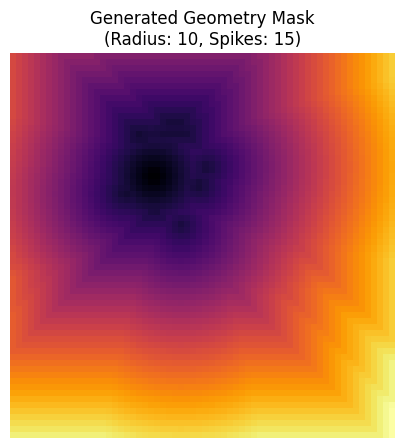

Ready for evaluation.


In [ ]:
#@title  2. Interactive Geometry
#@markdown Adjust the parameters below to sculpt a highly irregular obstacle. The AI must route the fluid around this exact shape.

core_radius = 10 #@param {type:"slider", min:5, max:15, step:1}
complexity_spikes = 15 #@param {type:"slider", min:3, max:15, step:1}
random_seed = 4634737 #@param {type:"integer"}

random.seed(random_seed)

def generate_custom_obstacle(core_r, spikes):
    primitives = []
    center_x, center_y = 37.5, 32.0

    # Core
    primitives.append(Sphere(center=vec(x=center_x, y=center_y), radius=core_r))

    # Spikes and Bumps
    for _ in range(spikes):
        angle = random.uniform(0, 2 * math.pi)
        dist = random.uniform(core_r * 0.3, core_r * 1.5)
        cx = center_x + math.cos(angle) * dist
        cy = center_y + math.sin(angle) * dist

        if random.choice([True, False]):
            primitives.append(Sphere(center=vec(x=cx, y=cy), radius=random.uniform(2, 5)))
        else:
            w, h = random.uniform(4, 12), random.uniform(4, 12)
            primitives.append(Box(x=(cx-w/2, cx+w/2), y=(cy-h/2, cy+h/2)))

    return union(*primitives)

# Generate the geometry
obstacle_geometry = generate_custom_obstacle(core_radius, complexity_spikes)

# Render the SDF Map
grid_size = [64, 64]
pressure_grid = CenteredGrid(0, extrapolation.BOUNDARY, x=grid_size[0], y=grid_size[1], bounds=Box(x=100, y=100))
sdf_tensor = obstacle_geometry.approximate_signed_distance(pressure_grid.points)
sdf_matrix = sdf_tensor.numpy('y,x')

plt.figure(figsize=(5, 5))
plt.title(f"Generated Geometry Mask\n(Radius: {core_radius}, Spikes: {complexity_spikes})")
plt.imshow(sdf_matrix, cmap='inferno')
plt.axis('off')
plt.show()

print("Ready for evaluation.")

Running Traditional Physics Engine...
   Done in 14.60 seconds.
Running Hybrid Spectral-Geometric AI...
Benchmarking
Phi-Flow Engine Time: 14.5980 seconds
Hybrid AI Inference:  2.9789 milliseconds
Acceleration:   4900.5x Faster
Mean Squared Error:   0.027843
Accuracy:    98.32%


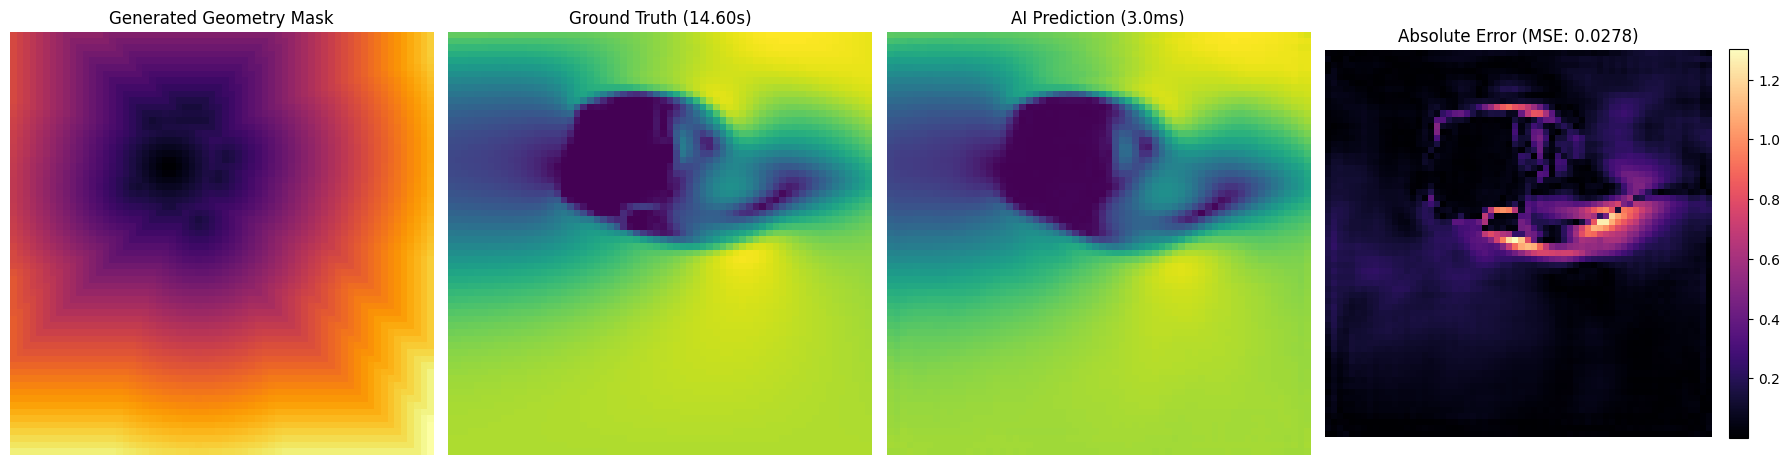

In [ ]:
#@title  3. CPU Physics vs. Hybrid AI
#@markdown This will compute the 30-step warm-up using Phi-Flow, then pass the geometry to the neural network for instant prediction.

print("Running Traditional Physics Engine...")
start_trad = time.perf_counter()

velocity_grid = StaggeredGrid(vec(x=5.0, y=0.0), extrapolation.BOUNDARY, x=grid_size[0], y=grid_size[1], bounds=Box(x=100, y=100))
obstacle = Obstacle(obstacle_geometry, velocity=[0, 0], angular_velocity=0)

for step in range(30):
    velocity_grid = advect.semi_lagrangian(velocity_grid, velocity_grid, dt=0.5)
    velocity_grid, pressure_grid = fluid.make_incompressible(velocity_grid, [obstacle])

centered_velocity = velocity_grid.at_centers()
vel_array = centered_velocity.values.numpy('y,x,vector')
true_u, true_v = vel_array[..., 0], vel_array[..., 1]

end_trad = time.perf_counter()
trad_time_ms = (end_trad - start_trad) * 1000

print(f"   Done in {trad_time_ms / 1000:.2f} seconds.")
print("Running Hybrid Spectral-Geometric AI...")

# Format for PyTorch
sdf_torch = torch.tensor(sdf_matrix, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
zeros = torch.zeros((1, 2, 64, 64), dtype=torch.float32).to(device)
x_in = torch.cat([sdf_torch, zeros], dim=1)

# AI Inference
start_ai = time.perf_counter()
with torch.no_grad():
    _, _, p64 = model(x_in)
end_ai = time.perf_counter()

ai_time_ms = (end_ai - start_ai) * 1000
speedup = trad_time_ms / ai_time_ms

pred_u, pred_v = p64[0, 0].cpu().numpy(), p64[0, 1].cpu().numpy()

# Metrics Math
true_wind = np.stack([true_u, true_v], axis=0)
pred_wind = np.stack([pred_u, pred_v], axis=0)
total_mse = (np.mean((true_u - pred_u)**2) + np.mean((true_v - pred_v)**2)) / 2.0

max_wind_speed = np.max(np.abs(true_wind)) + 1e-5
mean_absolute_error = np.mean(np.abs(true_wind - pred_wind))
accuracy_percentage = max(0.0, (1.0 - (mean_absolute_error / max_wind_speed))) * 100.0


print("Benchmarking")
print("="*40)
print(f"Phi-Flow Engine Time: {trad_time_ms / 1000:.4f} seconds")
print(f"Hybrid AI Inference:  {ai_time_ms:.4f} milliseconds")
print(f"Acceleration:   {speedup:.1f}x Faster")
print(f"Mean Squared Error:   {total_mse:.6f}")
print(f"Accuracy:    {accuracy_percentage:.2f}%")


# Visualization
gt_mag = np.sqrt(true_u**2 + true_v**2)
ai_mag = np.sqrt(pred_u**2 + pred_v**2)
error_map = np.abs(gt_mag - ai_mag)

plt.figure(figsize=(18, 5))
plt.subplot(1, 4, 1)
plt.title("Generated Geometry Mask")
plt.imshow(sdf_matrix, cmap='inferno')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title(f"Ground Truth ({trad_time_ms / 1000:.2f}s)")
plt.imshow(gt_mag, cmap='viridis')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title(f"AI Prediction ({ai_time_ms:.1f}ms)")
plt.imshow(ai_mag, cmap='viridis')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title(f"Absolute Error (MSE: {total_mse:.4f})")
plt.imshow(error_map, cmap='magma')
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')

plt.tight_layout()
plt.show()